# Exercice 4 : Régression sur un dataset
## Comparaison de plusieurs méthodes de régression avec optimisation des hyperparamètres

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [91]:
X_train = np.load('data/X_train.npy')
X_test = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test = np.load('data/y_test.npy')

print(f"Forme X_train : {X_train.shape}")
print(f"Forme X_test : {X_test.shape}")
print(f"Forme y_train : {y_train.shape}")
print(f"Forme y_test : {y_test.shape}")

Forme X_train : (200, 200)
Forme X_test : (200, 200)
Forme y_train : (200, 1)
Forme y_test : (200, 1)


Statistiques descriptives

X_train - Min: 0.0000, Max: 1.0000, Mean: 0.4984, Std: 0.2893
X_test - Min: 0.0000, Max: 1.0000, Mean: 0.4993, Std: 0.2891

y_train - Min: 1.9300, Max: 7.4648, Mean: 4.9068, Std: 0.9454
y_test - Min: 2.2818, Max: 7.4820, Mean: 5.0649, Std: 0.8580


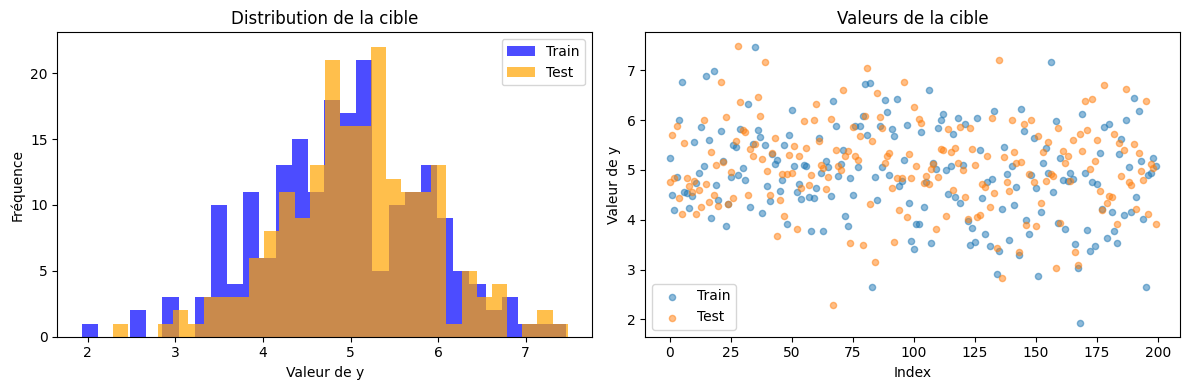

In [92]:
print("Statistiques descriptives")
print(f"\nX_train - Min: {X_train.min():.4f}, Max: {X_train.max():.4f}, Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"X_test - Min: {X_test.min():.4f}, Max: {X_test.max():.4f}, Mean: {X_test.mean():.4f}, Std: {X_test.std():.4f}")
print(f"\ny_train - Min: {y_train.min():.4f}, Max: {y_train.max():.4f}, Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"y_test - Min: {y_test.min():.4f}, Max: {y_test.max():.4f}, Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue')
axes[0].hist(y_test, bins=30, alpha=0.7, label='Test', color='orange')
axes[0].set_xlabel('Valeur de y')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la cible')
axes[0].legend()

axes[1].scatter(range(len(y_train)), y_train, alpha=0.5, label='Train', s=20)
axes[1].scatter(range(len(y_test)), y_test, alpha=0.5, label='Test', s=20)
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Valeur de y')
axes[1].set_title('Valeurs de la cible')
axes[1].legend()
plt.tight_layout()
plt.show()

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées")
print(f"X_train_scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"X_test_scaled - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

Données normalisées
X_train_scaled - Mean: 0.000000, Std: 1.000000
X_test_scaled - Mean: 0.002503, Std: 1.007813


## Méthode 1 : Régression Lasso (Sélection de variables L1)

In [94]:
print("LASSO REGRESSOR")
print("Optimisation des hyperparamètres via GridSearchCV")

param_grid_lasso = {
    'alpha': np.logspace(-4, 2, 100)
}

lasso = Lasso(max_iter=10000, random_state=42)
grid_search_lasso = GridSearchCV(
    lasso,
    param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train_scaled, y_train)

print(f"Meilleurs hyperparamètres : {grid_search_lasso.best_params_}")
print(f"Meilleur score CV (R^2) : {grid_search_lasso.best_score_:.6f}\n")

LASSO REGRESSOR
Optimisation des hyperparamètres via GridSearchCV
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Meilleurs hyperparamètres : {'alpha': np.float64(0.023101297000831605)}
Meilleur score CV (R^2) : 0.924823



In [95]:
lasso_best = grid_search_lasso.best_estimator_

y_train_pred_lasso = lasso_best.predict(X_train_scaled)
y_test_pred_lasso = lasso_best.predict(X_test_scaled)

r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

print(f"Résultats Lasso")
print(f"Train - R^2: {r2_train_lasso:.6f}, MSE: {mse_train_lasso:.6f}")
print(f"Test  - R^2: {r2_test_lasso:.6f}, MSE: {mse_test_lasso:.6f}")

nb_variables_utiles = np.sum(lasso_best.coef_ != 0)
print(f"Variables conservées par le Lasso : {nb_variables_utiles} / {X_train.shape[1]}")

Résultats Lasso
Train - R^2: 0.956474, MSE: 0.038904
Test  - R^2: 0.922981, MSE: 0.056701
Variables conservées par le Lasso : 30 / 200


## Méthode 2 : Ridge Regression avec optimisation

In [96]:
print("\nRIDGE REGRESSION")
print("Optimisation des hyperparamètres via GridSearchCV")

alphas = np.logspace(-3, 3, 50)

ridge = Ridge()
grid_search_ridge = GridSearchCV(
    ridge,
    {'alpha': alphas},
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search_ridge.fit(X_train_scaled, y_train)

print(f"Meilleur alpha : {grid_search_ridge.best_params_['alpha']:.6f}")
print(f"Meilleur score CV (R²) : {grid_search_ridge.best_score_:.6f}")


RIDGE REGRESSION
Optimisation des hyperparamètres via GridSearchCV
Meilleur alpha : 10.985411
Meilleur score CV (R²) : 0.570871


In [97]:
ridge_best = grid_search_ridge.best_estimator_

y_train_pred_ridge = ridge_best.predict(X_train_scaled)
y_test_pred_ridge = ridge_best.predict(X_test_scaled)

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"Résultats Ridge")
print(f"Train - R^2: {r2_train_ridge:.6f}, MSE: {mse_train_ridge:.6f}, MAE: {mae_train_ridge:.6f}")
print(f"Test  - R^2: {r2_test_ridge:.6f}, MSE: {mse_test_ridge:.6f}, MAE: {mae_test_ridge:.6f}")

Résultats Ridge
Train - R^2: 0.988889, MSE: 0.009931, MAE: 0.078292
Test  - R^2: 0.713659, MSE: 0.210801, MAE: 0.367200


## Comparaison des résultats

In [98]:
results_df = pd.DataFrame({
    'Modèle': ['Lasso', 'Ridge'],
    'R² Train': [r2_train_lasso, r2_train_ridge],
    'R² Test': [r2_test_lasso, r2_test_ridge],
    'MSE Train': [mse_train_lasso, mse_train_ridge],
    'MSE Test': [mse_test_lasso, mse_test_ridge],
    'MAE Train': [mae_train_lasso, mae_train_ridge],
    'MAE Test': [mae_test_lasso, mae_test_ridge]
})

print("COMPARAISON GLOBALE")
print(results_df.to_string(index=False))

best_idx = results_df['R² Test'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modèle']
best_r2_test = results_df.loc[best_idx, 'R² Test']

print(f"\nMeilleur modèle : {best_model_name} avec R^2 Test = {best_r2_test:.6f}")
if best_r2_test >= 0.88:
    print(f"atteint : R^2 Test ({best_r2_test:.6f}) >= 0.88")
else:
    print(f"non atteint : R^2 Test ({best_r2_test:.6f}) < 0.88")

COMPARAISON GLOBALE
Modèle  R² Train  R² Test  MSE Train  MSE Test  MAE Train  MAE Test
 Lasso  0.956474 0.922981   0.038904  0.056701   0.153475  0.194349
 Ridge  0.988889 0.713659   0.009931  0.210801   0.078292  0.367200

Meilleur modèle : Lasso avec R^2 Test = 0.922981
atteint : R^2 Test (0.922981) >= 0.88


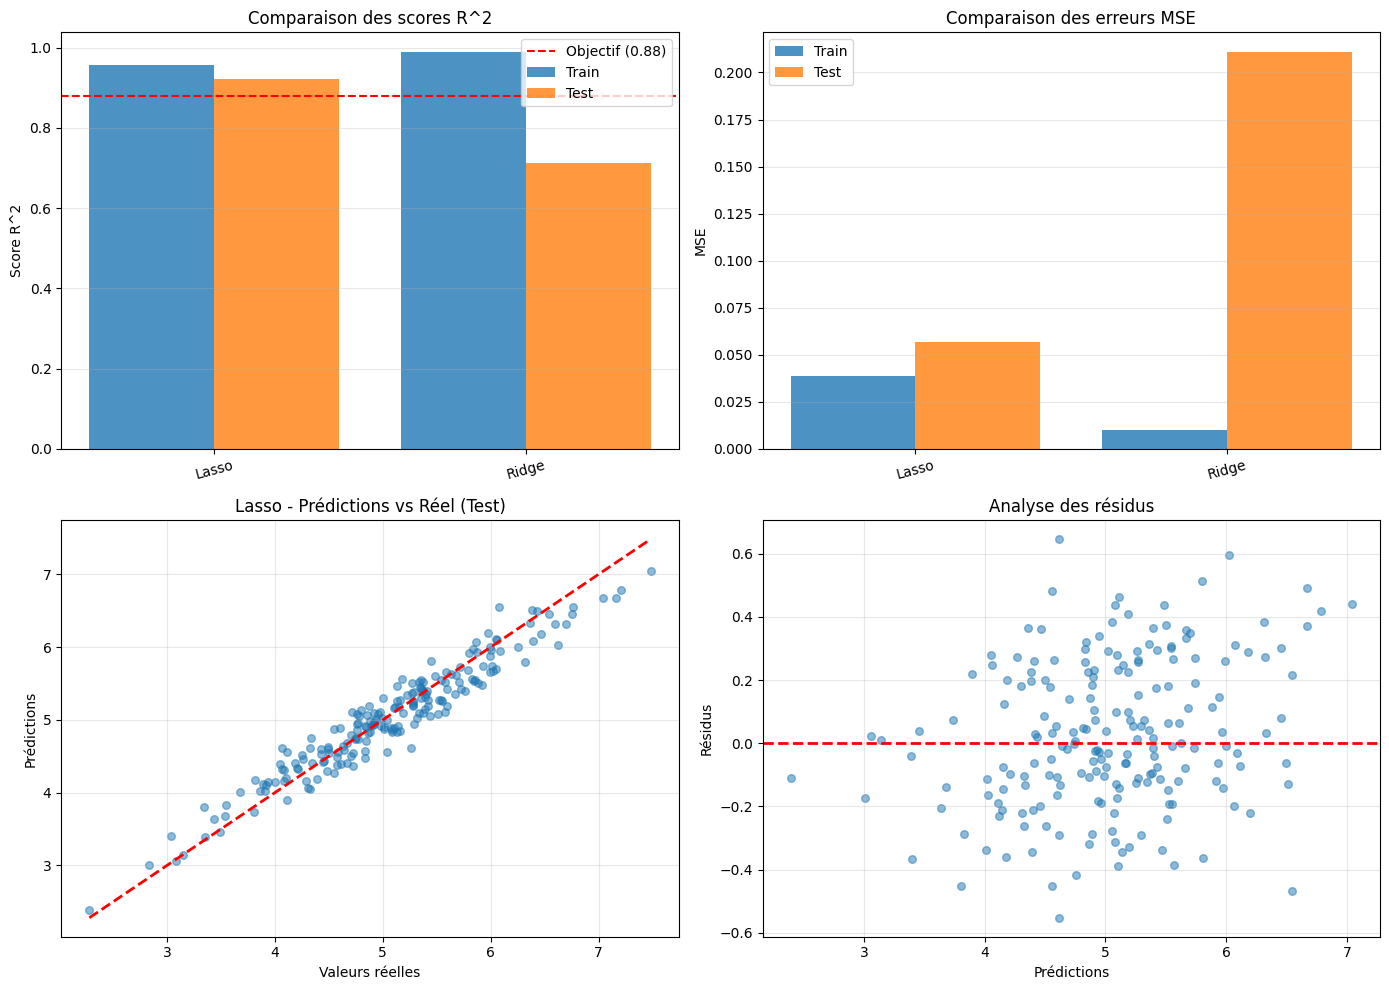

In [99]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['Lasso', 'Ridge']
x_pos = np.arange(len(models))

axes[0, 0].bar(x_pos - 0.2, [r2_train_lasso, r2_train_ridge], 0.4, label='Train', alpha=0.8)
axes[0, 0].bar(x_pos + 0.2, [r2_test_lasso, r2_test_ridge], 0.4, label='Test', alpha=0.8)
axes[0, 0].axhline(y=0.88, color='red', linestyle='--', label='Objectif (0.88)')
axes[0, 0].set_ylabel('Score R^2')
axes[0, 0].set_title('Comparaison des scores R^2')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=15, ha='center')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(x_pos - 0.2, [mse_train_lasso, mse_train_ridge], 0.4, label='Train', alpha=0.8)
axes[0, 1].bar(x_pos + 0.2, [mse_test_lasso, mse_test_ridge], 0.4, label='Test', alpha=0.8)
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('Comparaison des erreurs MSE')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=15, ha='center')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

if best_idx == 0:
    y_pred = y_test_pred_lasso.flatten()
    title = 'Lasso - Prédictions vs Réel (Test)'
else:
    y_pred = y_test_pred_ridge.flatten()
    title = 'Ridge - Prédictions vs Réel (Test)'

y_test_flat = np.asarray(y_test).flatten()

axes[1, 0].scatter(y_test_flat, y_pred, alpha=0.5, s=30)
axes[1, 0].plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Valeurs réelles')
axes[1, 0].set_ylabel('Prédictions')
axes[1, 0].set_title(title)
axes[1, 0].grid(alpha=0.3)

residuals = (y_test_flat - y_pred).flatten()
axes[1, 1].scatter(y_pred, residuals, alpha=0.5, s=30)
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Prédictions')
axes[1, 1].set_ylabel('Résidus')
axes[1, 1].set_title('Analyse des résidus')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

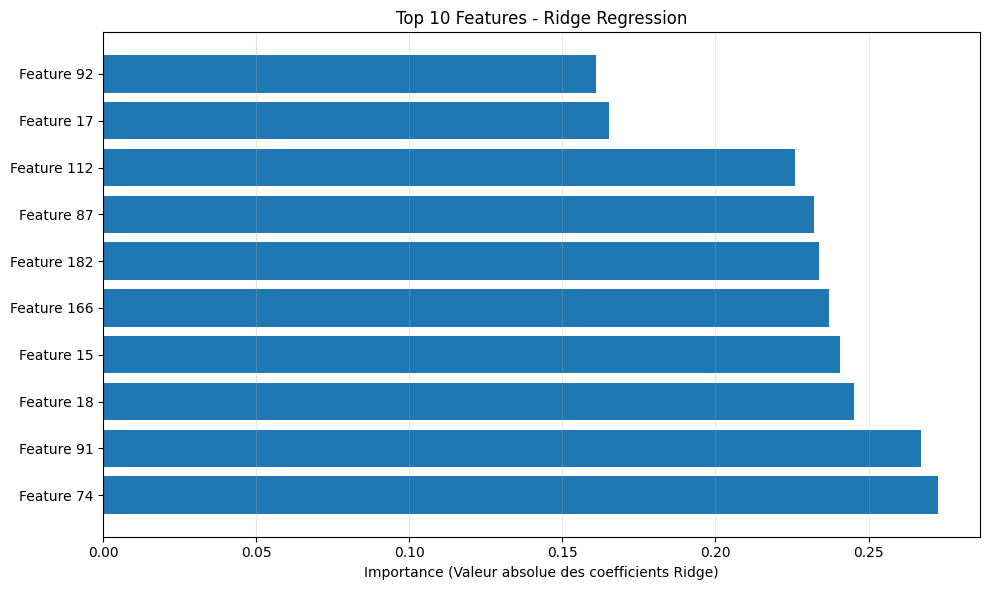

Importance des features (Ridge Regression) :
  Feature 74: 0.272790
  Feature 91: 0.267246
  Feature 18: 0.245217
  Feature 15: 0.240774
  Feature 166: 0.237148
  Feature 182: 0.233681
  Feature 87: 0.232045
  Feature 112: 0.225941
  Feature 17: 0.165158
  Feature 92: 0.160902


In [100]:
feature_importance = np.abs(ridge_best.coef_).flatten()
feature_names = [f'Feature {i}' for i in range(len(feature_importance))]

sorted_idx = np.argsort(feature_importance)[::-1][:10]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Importance (Valeur absolue des coefficients Ridge)')
ax.set_title('Top 10 Features - Ridge Regression')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Importance des features (Ridge Regression) :")
for idx in sorted_idx:
    print(f"  {feature_names[idx]}: {feature_importance[idx]:.6f}")

In [101]:
results_df = pd.DataFrame({
    'Modèle': ['Lasso', 'Ridge'],
    'R² Train': [r2_train_lasso, r2_train_ridge],
    'R² Test': [r2_test_lasso, r2_test_ridge],
    'MSE Train': [mse_train_lasso, mse_train_ridge],
    'MSE Test': [mse_test_lasso, mse_test_ridge],
    'MAE Train': [mae_train_lasso, mae_train_ridge],
    'MAE Test': [mae_test_lasso, mae_test_ridge]
})

print("COMPARAISON GLOBALE")
print(results_df.to_string(index=False))

best_idx = results_df['R² Test'].idxmax()
best_model_name = results_df.loc[best_idx, 'Modèle']
best_r2_test = results_df.loc[best_idx, 'R² Test']

print("RÉSUMÉ FINAL")
print(f"Meilleur modèle sélectionné : {best_model_name}")
print(f"Performance sur le test set : R^2 = {best_r2_test:.6f}")
print(f"Objectif (R^2 >= 0.88) : { 'atteint' if best_r2_test >= 0.88 else 'NON ATTEINT' }")

COMPARAISON GLOBALE
Modèle  R² Train  R² Test  MSE Train  MSE Test  MAE Train  MAE Test
 Lasso  0.956474 0.922981   0.038904  0.056701   0.153475  0.194349
 Ridge  0.988889 0.713659   0.009931  0.210801   0.078292  0.367200
RÉSUMÉ FINAL
Meilleur modèle sélectionné : Lasso
Performance sur le test set : R^2 = 0.922981
Objectif (R^2 >= 0.88) : atteint


In [102]:
print("RÉSUMÉ FINAL")
print(f"\nMeilleur modèle sélectionné : {best_model_name}")
print(f"Performance sur le test set : R^2 = {best_r2_test:.6f}")
print(f"Objectif (R^2 ≥ 0.88) : {'ATTEINT' if best_r2_test >= 0.88 else 'NON ATTEINT'}")
print(f"\nMétriques complètes du meilleur modèle sur le test set:")
print(f"  - R^2 Score: {best_r2_test:.6f}")
print(f"  - MSE: {results_df.loc[best_idx, 'MSE Test']:.6f}")
print(f"  - MAE: {results_df.loc[best_idx, 'MAE Test']:.6f}")
print(f"  - RMSE: {np.sqrt(results_df.loc[best_idx, 'MSE Test']):.6f}")

RÉSUMÉ FINAL

Meilleur modèle sélectionné : Lasso
Performance sur le test set : R^2 = 0.922981
Objectif (R^2 ≥ 0.88) : ATTEINT

Métriques complètes du meilleur modèle sur le test set:
  - R^2 Score: 0.922981
  - MSE: 0.056701
  - MAE: 0.194349
  - RMSE: 0.238119
